In [5]:
import cv2
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
import requests

In [2]:
def load_image_from_url(url):

    response = requests.get(url)

    img = Image.open(
        BytesIO(response.content)
    )

    img = np.array(img)

    return img

(np.float64(-0.5), np.float64(2999.5), np.float64(3749.5), np.float64(-0.5))

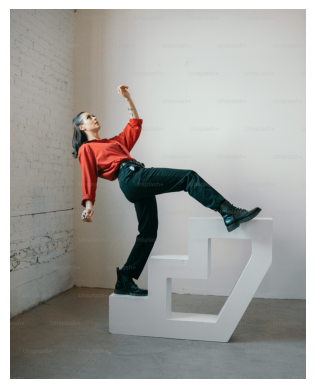

In [7]:
image_url = "https://plus.unsplash.com/premium_photo-1669951867301-4837c140c425?fm=jpg&q=60&w=3000&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxzZWFyY2h8MXx8aHVtYW4lMjBwb3NlfGVufDB8fDB8fHww"

image = load_image_from_url(image_url)

plt.imshow(image)
plt.axis("off")

In [8]:
pose_model = hub.load(
"https://tfhub.dev/google/movenet/singlepose/lightning/4"
)

movenet = pose_model.signatures['serving_default']

In [10]:
input_image = tf.image.resize_with_pad(
np.expand_dims(image, axis=0),
192,
192
)

input_image = tf.cast(input_image, dtype=tf.int32)

In [11]:
outputs = movenet(input_image)

keypoints = outputs['output_0'].numpy()

In [12]:
height, width, _ = image.shape

for kp in keypoints[0][0]:

    y, x, confidence = kp

    if confidence > 0.3:

        cv2.circle(
            image,
            (int(x * width), int(y * height)),
            5,
            (0,255,0),
            -1
        )

In [17]:
edges = [
(5,7),(7,9),
(6,8),(8,10),
(5,6),
(5,11),(6,12),
(11,12),
(11,13),(13,15),
(12,14),(14,16)
]

In [18]:
for edge in edges:

    p1 = keypoints[0][0][edge[0]]
    p2 = keypoints[0][0][edge[1]]

    y1,x1,_ = p1
    y2,x2,_ = p2

    cv2.line(
        image,
        (int(x1*width),int(y1*height)),
        (int(x2*width),int(y2*height)),
        (255,0,0),
        2
    )

In [22]:
detector = hub.load(
"https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2"
)

In [23]:
img_tensor = tf.convert_to_tensor(image)

img_tensor = img_tensor[tf.newaxis,...]

detections = detector(img_tensor)

In [24]:
boxes = detections["detection_boxes"][0].numpy()
scores = detections["detection_scores"][0].numpy()

for i in range(len(scores)):

    if scores[i] > 0.5:

        y1,x1,y2,x2 = boxes[i]

        cv2.rectangle(
            image,
            (int(x1*width),int(y1*height)),
            (int(x2*width),int(y2*height)),
            (0,255,0),
            2
        )

(np.float64(-0.5), np.float64(2999.5), np.float64(3749.5), np.float64(-0.5))

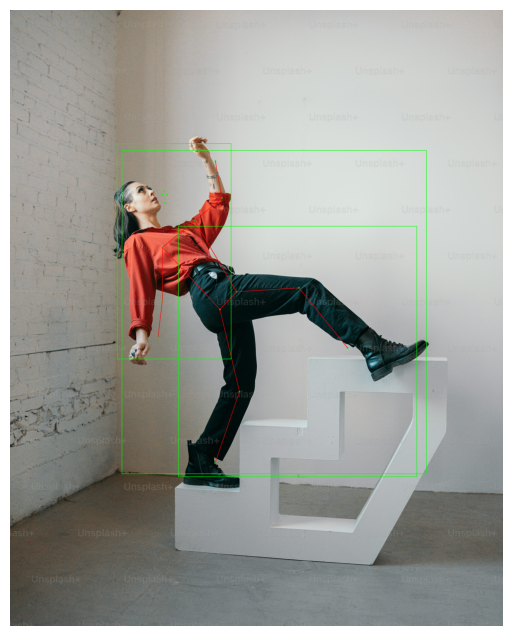

In [25]:
plt.figure(figsize=(8,8))

plt.imshow(image)

plt.axis("off")

In [26]:
def load_image_from_url(url):

    response = requests.get(url)

    img = Image.open(BytesIO(response.content))

    img = np.array(img)

    return img

In [28]:
image_url = "https://media.istockphoto.com/id/1457277458/vector/3d-vector-set-of-beach-and-sea-summer-journey-time-to-travel-concept.jpg?s=612x612&w=0&k=20&c=_-Oh8HAyDXolIM6WCfSsWEF1-gLUdJyocmG9-pXXikc="

image = load_image_from_url(image_url)

(np.float64(-0.5), np.float64(611.5), np.float64(611.5), np.float64(-0.5))

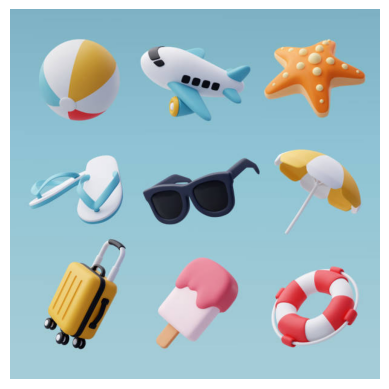

In [29]:
plt.imshow(image)
plt.axis("off")

In [30]:
detector = hub.load(
"https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2"
)

In [31]:
image_tensor = tf.convert_to_tensor(image)

image_tensor = image_tensor[tf.newaxis,...]

In [32]:
detections = detector(image_tensor)

In [33]:
boxes = detections["detection_boxes"][0].numpy()

scores = detections["detection_scores"][0].numpy()

classes = detections["detection_classes"][0].numpy()

In [36]:
height, width, _ = image.shape

for i in range(len(scores)):

    if scores[i] > 0.2:

        y1,x1,y2,x2 = boxes[i]

        cv2.rectangle(
            image,
            (int(x1*width),int(y1*height)),
            (int(x2*width),int(y2*height)),
            (0,255,0),
            2
        )

(np.float64(-0.5), np.float64(611.5), np.float64(611.5), np.float64(-0.5))

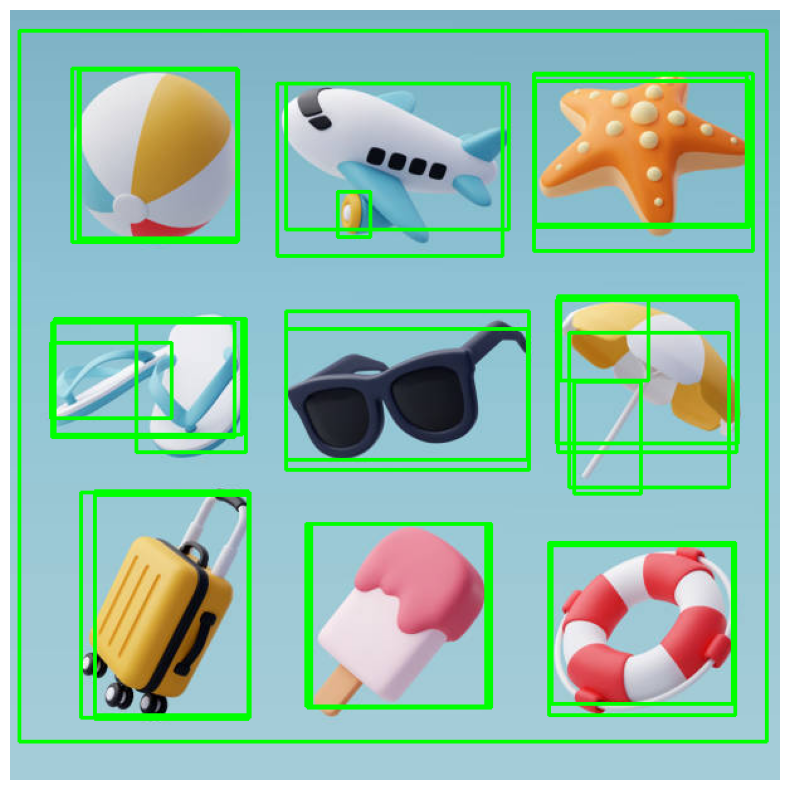

In [37]:
plt.figure(figsize=(10,10))

plt.imshow(image)

plt.axis("off")